In [1]:
import pandas as pd
import numpy as np
import joblib

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Load processed dataset
df = pd.read_csv("../data/processed/final_features.csv")

# Separate features and target
X = df.drop("NObeyesdad", axis=1)
y = df["NObeyesdad"]

# Recreate the same train-test split used during model training
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Load saved model and preprocessing pipeline
loaded_model = joblib.load("../models/best_model.pkl")
loaded_preprocessor = joblib.load("../models/preprocessing_pipeline.pkl")

# Transform test data
X_test_processed = loaded_preprocessor.transform(X_test)

print("Evaluation data loaded successfully!")
print("-----------------------------------")
print("Dataset shape:", df.shape)
print("Test set shape:", X_test.shape)
print("Processed test shape:", X_test_processed.shape)
print("Model:", type(loaded_model).__name__)
print("Preprocessor:", type(loaded_preprocessor).__name__)

Evaluation data loaded successfully!
-----------------------------------
Dataset shape: (2087, 17)
Test set shape: (418, 16)
Processed test shape: (418, 31)
Model: XGBClassifier
Preprocessor: ColumnTransformer


In [2]:
# Generate predictions using the saved final model
y_pred_encoded = loaded_model.predict(X_test_processed)

# Recreate the same class mapping used during training
target_classes = sorted(y_train.unique())
class_to_int = {label: i for i, label in enumerate(target_classes)}
int_to_class = {i: label for label, i in class_to_int.items()}

# Convert encoded predictions back to original class names
y_pred = pd.Series(y_pred_encoded).map(int_to_class)

print("Predictions generated successfully!")
print("-----------------------------------")
print("Number of predictions:", len(y_pred))
print("Actual test samples:", len(y_test))
print("All predictions generated:", len(y_pred) == len(y_test))

print("\nFirst 10 Predictions:")
print("---------------------")
print(y_pred.head(10).to_string(index=False))

Predictions generated successfully!
-----------------------------------
Number of predictions: 418
Actual test samples: 418
All predictions generated: True

First 10 Predictions:
---------------------
Overweight_Level_II
     Obesity_Type_I
   Obesity_Type_III
 Overweight_Level_I
     Obesity_Type_I
     Obesity_Type_I
     Obesity_Type_I
Overweight_Level_II
    Obesity_Type_II
    Obesity_Type_II


In [3]:
# Calculate final test accuracy
final_accuracy = accuracy_score(y_test, y_pred)

print("Final Model Accuracy")
print("--------------------")
print(f"Test Accuracy: {final_accuracy * 100:.2f}%")
print(f"Correct Predictions: {(y_pred == y_test.reset_index(drop=True)).sum()} / {len(y_test)}")
print(f"Incorrect Predictions: {(y_pred != y_test.reset_index(drop=True)).sum()} / {len(y_test)}")

Final Model Accuracy
--------------------
Test Accuracy: 96.89%
Correct Predictions: 405 / 418
Incorrect Predictions: 13 / 418


In [4]:
# Generate detailed classification report
report = classification_report(
    y_test,
    y_pred,
    target_names=target_classes,
    digits=3
)

print("Classification Report")
print("=====================")
print(report)

Classification Report
                     precision    recall  f1-score   support

Insufficient_Weight      1.000     1.000     1.000        53
      Normal_Weight      0.930     0.930     0.930        57
     Obesity_Type_I      0.986     0.971     0.978        70
    Obesity_Type_II      0.984     1.000     0.992        60
   Obesity_Type_III      1.000     0.985     0.992        65
 Overweight_Level_I      0.909     0.909     0.909        55
Overweight_Level_II      0.966     0.983     0.974        58

           accuracy                          0.969       418
          macro avg      0.968     0.968     0.968       418
       weighted avg      0.969     0.969     0.969       418



In [5]:
# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=target_classes)

print("Confusion Matrix")
print("================")
print("Rows = Actual Class")
print("Columns = Predicted Class\n")

# Print class labels in order
print("Class order:")
for i, label in enumerate(target_classes):
    print(f"{i}: {label}")

print("\nConfusion Matrix Values:")
print(cm)

Confusion Matrix
Rows = Actual Class
Columns = Predicted Class

Class order:
0: Insufficient_Weight
1: Normal_Weight
2: Obesity_Type_I
3: Obesity_Type_II
4: Obesity_Type_III
5: Overweight_Level_I
6: Overweight_Level_II

Confusion Matrix Values:
[[53  0  0  0  0  0  0]
 [ 0 53  0  0  0  4  0]
 [ 0  0 68  0  0  1  1]
 [ 0  0  0 60  0  0  0]
 [ 0  0  0  1 64  0  0]
 [ 0  4  0  0  0 50  1]
 [ 0  0  1  0  0  0 57]]


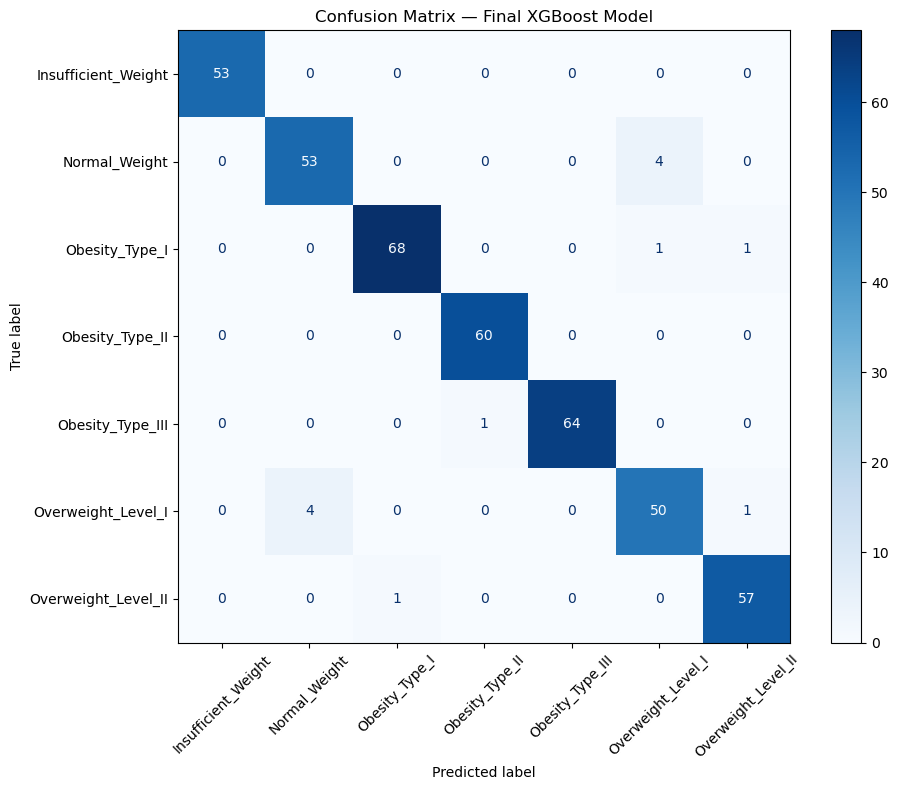


Exact Confusion Matrix Values
                     Insufficient_Weight  Normal_Weight  Obesity_Type_I  \
Insufficient_Weight                   53              0               0   
Normal_Weight                          0             53               0   
Obesity_Type_I                         0              0              68   
Obesity_Type_II                        0              0               0   
Obesity_Type_III                       0              0               0   
Overweight_Level_I                     0              4               0   
Overweight_Level_II                    0              0               1   

                     Obesity_Type_II  Obesity_Type_III  Overweight_Level_I  \
Insufficient_Weight                0                 0                   0   
Normal_Weight                      0                 0                   4   
Obesity_Type_I                     0                 0                   1   
Obesity_Type_II                   60                 0  

In [6]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Create confusion matrix display
fig, ax = plt.subplots(figsize=(10, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=target_classes
)

disp.plot(
    ax=ax,
    xticks_rotation=45,
    values_format="d",
    cmap="Blues"
)

plt.title("Confusion Matrix — Final XGBoost Model")
plt.tight_layout()
plt.show()

# Print exact values behind the graph
print("\nExact Confusion Matrix Values")
print("=============================")
print(pd.DataFrame(cm, index=target_classes, columns=target_classes))

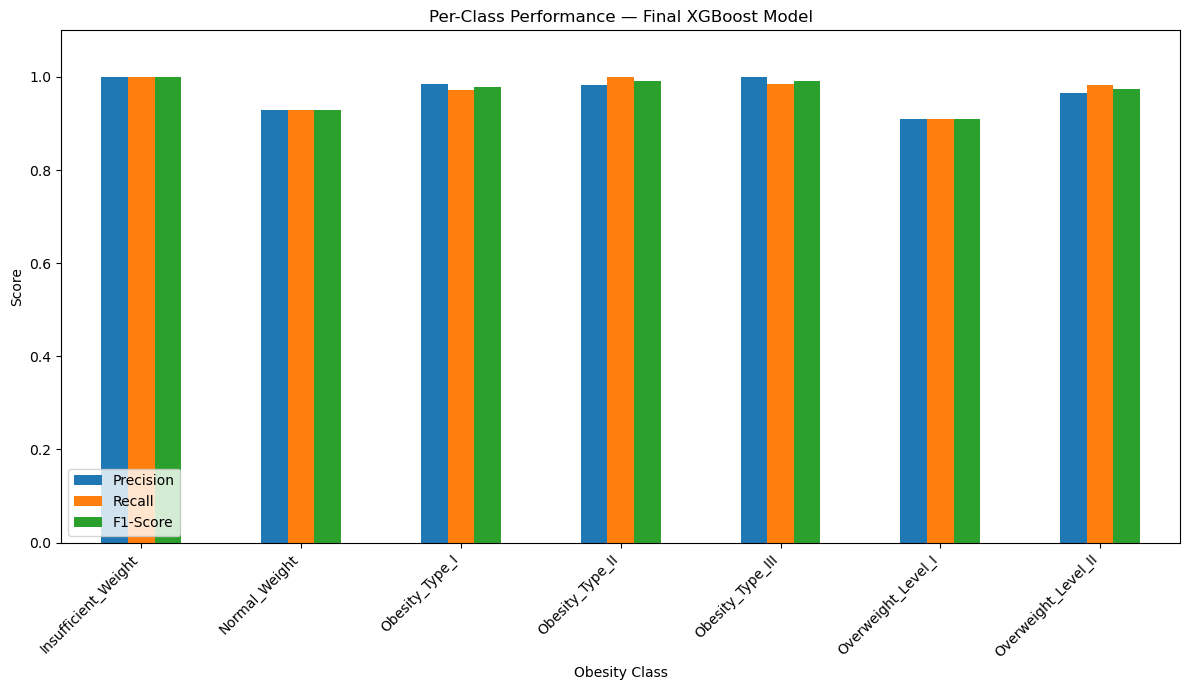


Exact Per-Class Metrics
              Class  Precision   Recall  F1-Score  Support
Insufficient_Weight   1.000000 1.000000  1.000000       53
      Normal_Weight   0.929825 0.929825  0.929825       57
     Obesity_Type_I   0.985507 0.971429  0.978417       70
    Obesity_Type_II   0.983607 1.000000  0.991736       60
   Obesity_Type_III   1.000000 0.984615  0.992248       65
 Overweight_Level_I   0.909091 0.909091  0.909091       55
Overweight_Level_II   0.966102 0.982759  0.974359       58

Macro Average
-------------
Precision: 0.968
Recall:    0.968
F1-Score:  0.968


In [7]:
from sklearn.metrics import precision_recall_fscore_support

# Calculate per-class metrics
precision, recall, f1, support = precision_recall_fscore_support(
    y_test,
    y_pred,
    labels=target_classes,
    zero_division=0
)

# Create DataFrame
class_metrics = pd.DataFrame({
    "Class": target_classes,
    "Precision": precision,
    "Recall": recall,
    "F1-Score": f1,
    "Support": support
})

# Plot
ax = class_metrics.set_index("Class")[[
    "Precision",
    "Recall",
    "F1-Score"
]].plot(
    kind="bar",
    figsize=(12, 7)
)

plt.title("Per-Class Performance — Final XGBoost Model")
plt.xlabel("Obesity Class")
plt.ylabel("Score")
plt.ylim(0, 1.1)
plt.xticks(rotation=45, ha="right")
plt.legend(loc="lower left")
plt.tight_layout()
plt.show()

# Print exact numerical values
print("\nExact Per-Class Metrics")
print("=======================")
print(class_metrics.to_string(index=False))

print("\nMacro Average")
print("-------------")
print(f"Precision: {precision.mean():.3f}")
print(f"Recall:    {recall.mean():.3f}")
print(f"F1-Score:  {f1.mean():.3f}")

In [8]:
from sklearn.model_selection import cross_val_score

# Perform 5-fold cross-validation on the training data only
cv_scores = cross_val_score(
    loaded_model,
    loaded_preprocessor.transform(X_train),
    y_train.map(class_to_int),
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

print("5-Fold Cross-Validation Results")
print("================================")

for i, score in enumerate(cv_scores, start=1):
    print(f"Fold {i}: {score * 100:.2f}%")

print("\nCross-Validation Summary")
print("------------------------")
print(f"Mean Accuracy: {cv_scores.mean() * 100:.2f}%")
print(f"Standard Deviation: {cv_scores.std() * 100:.2f}%")
print(f"Minimum Accuracy: {cv_scores.min() * 100:.2f}%")
print(f"Maximum Accuracy: {cv_scores.max() * 100:.2f}%")

5-Fold Cross-Validation Results
Fold 1: 95.81%
Fold 2: 97.31%
Fold 3: 97.90%
Fold 4: 95.81%
Fold 5: 97.00%

Cross-Validation Summary
------------------------
Mean Accuracy: 96.76%
Standard Deviation: 0.83%
Minimum Accuracy: 95.81%
Maximum Accuracy: 97.90%


In [9]:
# Final model performance summary

final_summary = pd.DataFrame({
    "Metric": [
        "Model",
        "Number of Classes",
        "Test Samples",
        "Test Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1-Score",
        "CV Mean Accuracy",
        "CV Standard Deviation"
    ],
    "Value": [
        type(loaded_model).__name__,
        len(target_classes),
        len(y_test),
        f"{final_accuracy * 100:.2f}%",
        f"{precision.mean() * 100:.2f}%",
        f"{recall.mean() * 100:.2f}%",
        f"{f1.mean() * 100:.2f}%",
        f"{cv_scores.mean() * 100:.2f}%",
        f"{cv_scores.std() * 100:.2f}%"
    ]
})

print("FINAL MODEL PERFORMANCE SUMMARY")
print("================================")
print(final_summary.to_string(index=False))

FINAL MODEL PERFORMANCE SUMMARY
               Metric         Value
                Model XGBClassifier
    Number of Classes             7
         Test Samples           418
        Test Accuracy        96.89%
      Macro Precision        96.77%
         Macro Recall        96.82%
       Macro F1-Score        96.80%
     CV Mean Accuracy        96.76%
CV Standard Deviation         0.83%


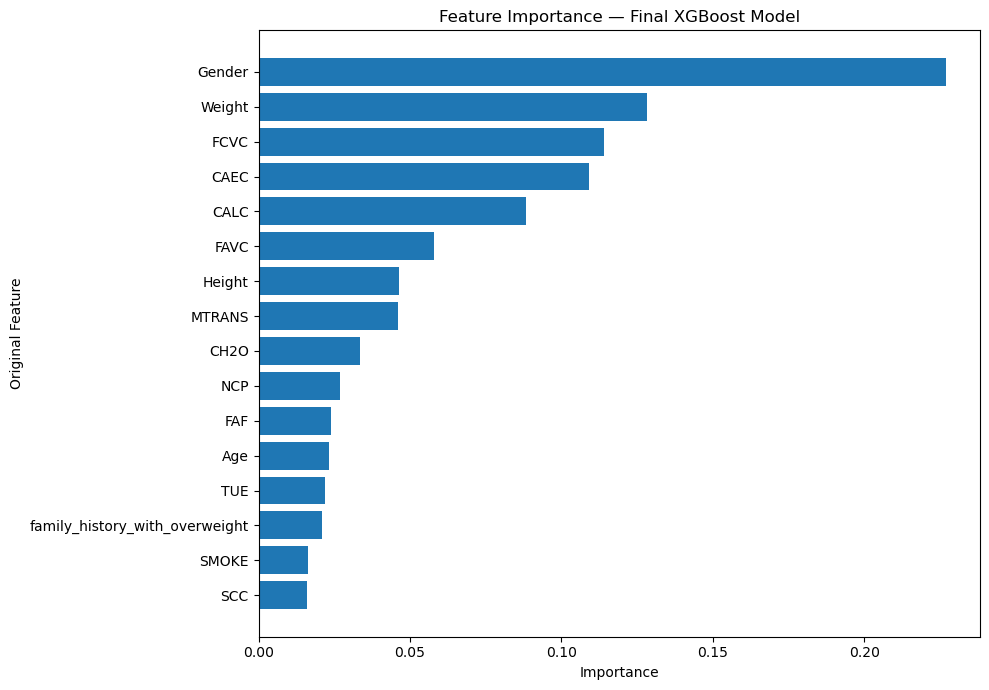


Exact Feature Importance Values
                       Feature  Importance
                        Gender    0.226899
                        Weight    0.128156
                          FCVC    0.114218
                          CAEC    0.109273
                          CALC    0.088237
                          FAVC    0.057877
                        Height    0.046323
                        MTRANS    0.046205
                          CH2O    0.033564
                           NCP    0.026802
                           FAF    0.023961
                           Age    0.023150
                           TUE    0.022007
family_history_with_overweight    0.021098
                         SMOKE    0.016222
                           SCC    0.016007

Importance Sum: 0.9999999


In [11]:
# Define the original feature groups
numerical_features = [
    "Age",
    "Height",
    "Weight",
    "FCVC",
    "NCP",
    "CH2O",
    "FAF",
    "TUE"
]

categorical_features = [
    "Gender",
    "family_history_with_overweight",
    "FAVC",
    "CAEC",
    "SMOKE",
    "SCC",
    "CALC",
    "MTRANS"
]

# Get feature names from the saved preprocessing pipeline
feature_names = loaded_preprocessor.get_feature_names_out()

# Get XGBoost feature importance
raw_importance = loaded_model.feature_importances_

# Create feature importance DataFrame
feature_importance = pd.DataFrame({
    "Transformed_Feature": feature_names,
    "Importance": raw_importance
})

# Aggregate one-hot encoded features back to the original 16 features
original_features = {}

for feature in X.columns:
    if feature in numerical_features:
        original_features[feature] = feature_importance[
            feature_importance["Transformed_Feature"] == f"num__{feature}"
        ]["Importance"].sum()
    else:
        original_features[feature] = feature_importance[
            feature_importance["Transformed_Feature"].str.startswith(
                f"cat__{feature}_"
            )
        ]["Importance"].sum()

aggregated_importance = pd.DataFrame({
    "Feature": list(original_features.keys()),
    "Importance": list(original_features.values())
}).sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

# Plot feature importance
plt.figure(figsize=(10, 7))

plt.barh(
    aggregated_importance["Feature"],
    aggregated_importance["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Feature Importance — Final XGBoost Model")
plt.xlabel("Importance")
plt.ylabel("Original Feature")
plt.tight_layout()
plt.show()


print("\nExact Feature Importance Values")
print("===============================")
print(aggregated_importance.to_string(index=False))

print("\nImportance Sum:", aggregated_importance["Importance"].sum())

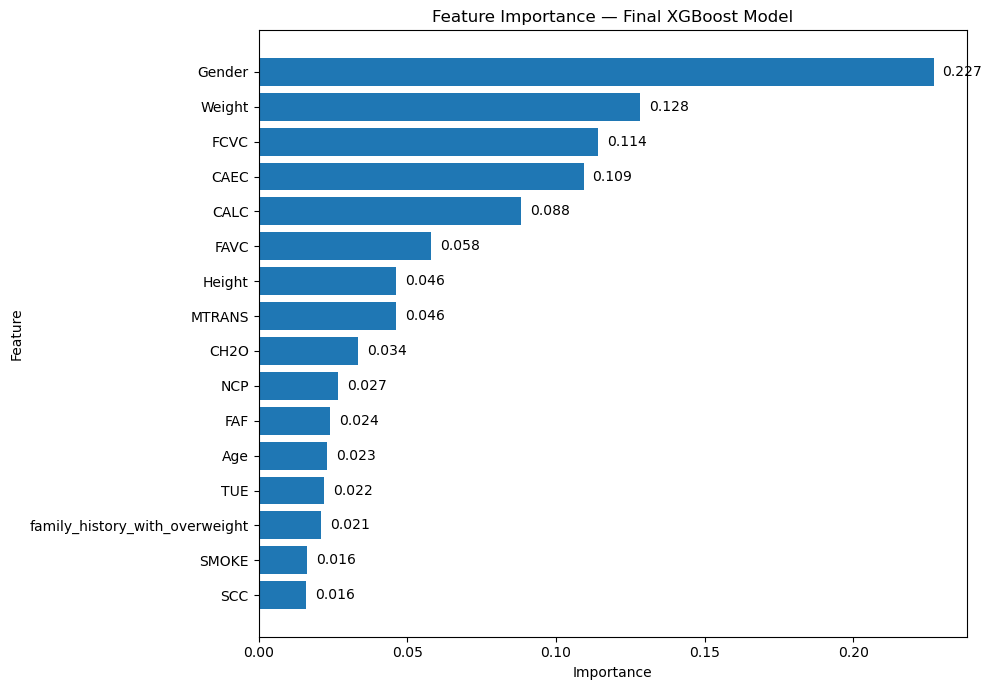


Feature Importance Used in the Graph
Gender                           0.226899
Weight                           0.128156
FCVC                             0.114218
CAEC                             0.109273
CALC                             0.088237
FAVC                             0.057877
Height                           0.046323
MTRANS                           0.046205
CH2O                             0.033564
NCP                              0.026802
FAF                              0.023961
Age                              0.023150
TUE                              0.022007
family_history_with_overweight   0.021098
SMOKE                            0.016222
SCC                              0.016007


In [12]:
# Plot feature importance with exact values

plot_data = aggregated_importance.sort_values("Importance", ascending=True)

plt.figure(figsize=(10, 7))

bars = plt.barh(
    plot_data["Feature"],
    plot_data["Importance"]
)

plt.title("Feature Importance — Final XGBoost Model")
plt.xlabel("Importance")
plt.ylabel("Feature")

# Add exact values to the bars
for bar, value in zip(bars, plot_data["Importance"]):
    plt.text(
        bar.get_width() + 0.003,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.3f}",
        va="center"
    )

plt.tight_layout()
plt.show()

print("\nFeature Importance Used in the Graph")
print("=====================================")

for _, row in aggregated_importance.iterrows():
    print(f"{row['Feature']:<32} {row['Importance']:.6f}")

In [13]:
# Final evaluation notes

print("FINAL MODEL EVALUATION — INTERPRETATION")
print("========================================\n")

print("1. Model Performance")
print("--------------------")
print("The final XGBoost model achieved 96.89% accuracy on the")
print("held-out test set of 418 samples.")
print("5-fold cross-validation on the training data achieved")
print("96.76% ± 0.83% accuracy.\n")

print("2. Classification Performance")
print("------------------------------")
print("The model achieved a macro F1-score of 96.80%, indicating")
print("consistently strong performance across all seven classes.")
print("The lowest class-level F1-score was 90.91% for")
print("Overweight_Level_I.\n")

print("3. Error Analysis")
print("------------------")
print("Most classification errors occurred between neighboring")
print("weight categories, particularly Normal_Weight and")
print("Overweight_Level_I.\n")

print("4. Feature Importance Interpretation")
print("------------------------------------")
print("XGBoost feature importance indicates which features were")
print("used most heavily by the trained model for tree splitting.")
print("It does NOT establish causal relationships.\n")

print("5. Important Modeling Limitation")
print("--------------------------------")
print("Weight and Height are among the most important predictive")
print("variables. Since obesity categories are strongly related")
print("to body measurements, high predictive performance is not")
print("equivalent to demonstrating that lifestyle variables cause")
print("obesity.\n")

print("6. BMI Handling")
print("---------------")
print("BMI was explored during EDA but was excluded from the final")
print("16-feature model. This avoids directly introducing a derived")
print("BMI variable while retaining Height and Weight as original")
print("input features.\n")

print("7. Generalization")
print("-----------------")
print("The close agreement between cross-validation accuracy and")
print("held-out test accuracy provides evidence of consistent")
print("performance on this dataset. Further validation on an")
print("independent external dataset would still be required before")
print("making claims about performance on other populations.")

FINAL MODEL EVALUATION — INTERPRETATION

1. Model Performance
--------------------
The final XGBoost model achieved 96.89% accuracy on the
held-out test set of 418 samples.
5-fold cross-validation on the training data achieved
96.76% ± 0.83% accuracy.

2. Classification Performance
------------------------------
The model achieved a macro F1-score of 96.80%, indicating
consistently strong performance across all seven classes.
The lowest class-level F1-score was 90.91% for
Overweight_Level_I.

3. Error Analysis
------------------
Most classification errors occurred between neighboring
weight categories, particularly Normal_Weight and
Overweight_Level_I.

4. Feature Importance Interpretation
------------------------------------
XGBoost feature importance indicates which features were
used most heavily by the trained model for tree splitting.
It does NOT establish causal relationships.

5. Important Modeling Limitation
--------------------------------
Weight and Height are among the most 